In [1]:
#run only once!
%load_ext autoreload
%autoreload 2
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Schuster_Resonators.approx_Schuster import *
from CPW.cpw import *
import scipy.io as sc
import scipy.signal as sig

In [3]:
def db(x):
    return 20*np.log10(x)

def linear(x):
    return 10**(x/20)


def w0_from_S21(S21, w, prominence):
    dip , _ = sig.find_peaks(-S21, prominence = prominence)
    w0 = w[dip[0]]
    return w0



## MWO


In [9]:
path = r'D:\AWR-MWO\202510-SiRes-NbTiN-Tres'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
dict_keys(['Tress-test10', 'V11'])


In [5]:
def cut_off(data, f_min, f_max):
    mask = (data['freq'] >= f_min) & (data['freq'] <= f_max)
    return {'freq': data['freq'][mask], 'amp': data['amp'][mask]}

# d['GeRes-SiSubs-Al-v4'] = cut_off(d['GeRes-SiSubs-Al-v4'], 4.8e9, 5.2e9)

# V19

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat', 'V13-diffFL.mat', 'V13.mat', 'V14.mat', 'V15.mat', 'V16.mat', 'V17.mat', 'V18.mat', 'V19.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
['V13-diffFL', 'mat']
['V13', 'mat']
['V14', 'mat']
['V15', 'mat']
['V16', 'mat']
['V17', 'mat']
['V18', 'mat']
['V19', 'mat']
dict_keys(['Tress-test10', 'V11', 'V13-diffFL', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19'])


C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\1761323655.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\1761323655.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)


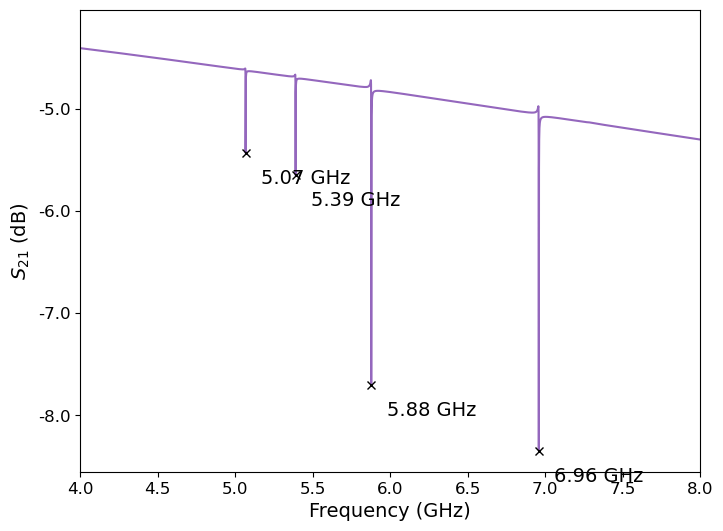

C0: [4.64774855e-14 4.38511703e-14 3.99570435e-14 3.42195908e-14]
Cc: [1.57284235e-15 1.45358914e-15 1.86415664e-15 1.71385817e-15]
Qc: [12201.83610255 12663.03960739  6517.51125343  5595.83523738]


In [34]:
path = r'D:\AWR-MWO\202510-SiRes-NbTiN-Tres'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V19'
filecsv = 'Tres-V19.csv'


f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.2)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(4, 8)
ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-Tres-NbTiN\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 4


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V18

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat', 'V13-diffFL.mat', 'V13.mat', 'V14.mat', 'V15.mat', 'V16.mat', 'V17.mat', 'V18.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
['V13-diffFL', 'mat']
['V13', 'mat']
['V14', 'mat']
['V15', 'mat']
['V16', 'mat']
['V17', 'mat']
['V18', 'mat']
dict_keys(['Tress-test10', 'V11', 'V13-diffFL', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18'])


C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\1256473447.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\1256473447.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)


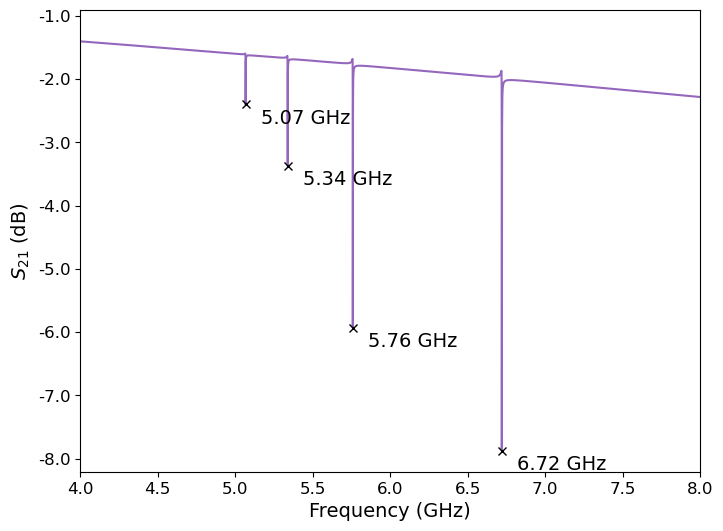

C0: [4.64763984e-14 4.41866725e-14 4.09985437e-14 3.56585465e-14]
Cc: [1.57267295e-15 1.69219355e-15 2.00393245e-15 2.24827089e-15]
Qc: [12204.1457453   9552.54469492  5918.96044321  3552.22855384]


In [33]:
path = r'D:\AWR-MWO\202510-SiRes-NbTiN-Tres'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V18'
filecsv = 'Tres-V18.csv'


f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.2)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(4, 8)
ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-Tres-NbTiN\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 4


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V17

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat', 'V13-diffFL.mat', 'V13.mat', 'V14.mat', 'V15.mat', 'V16.mat', 'V17.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
['V13-diffFL', 'mat']
['V13', 'mat']
['V14', 'mat']
['V15', 'mat']
['V16', 'mat']
['V17', 'mat']
dict_keys(['Tress-test10', 'V11', 'V13-diffFL', 'V13', 'V14', 'V15', 'V16', 'V17'])


C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\2125222610.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\2125222610.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)


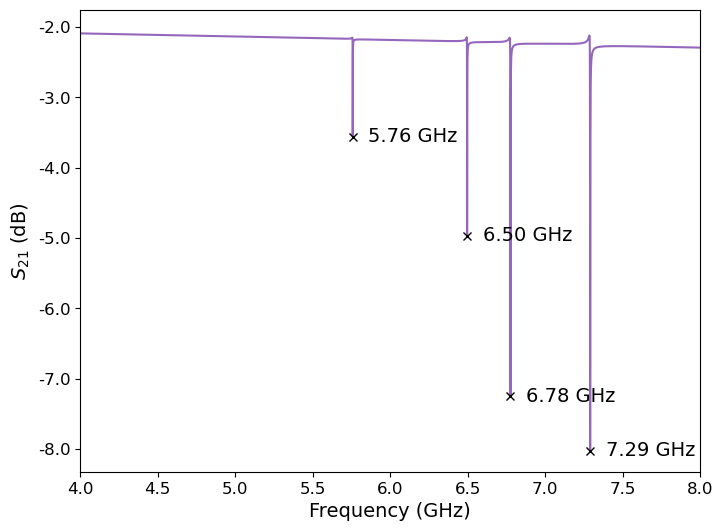

C0: [4.06807465e-14 3.60914103e-14 2.91804902e-14 3.38872475e-14]
Cc: [2.35526475e-15 2.88068895e-15 4.58860840e-15 3.87580614e-15]
Qc: [4288.60383305 2301.18644474  753.43714011 1097.65437403]


In [32]:
path = r'D:\AWR-MWO\202510-SiRes-NbTiN-Tres'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V17'
filecsv = 'Tres-V17.csv'


f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.2)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(4, 8)
ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-Tres-NbTiN\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 4


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V16

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat', 'V13-diffFL.mat', 'V13.mat', 'V14.mat', 'V15.mat', 'V16.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
['V13-diffFL', 'mat']
['V13', 'mat']
['V14', 'mat']
['V15', 'mat']
['V16', 'mat']
dict_keys(['Tress-test10', 'V11', 'V13-diffFL', 'V13', 'V14', 'V15', 'V16'])


C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\3282749883.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\3282749883.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)


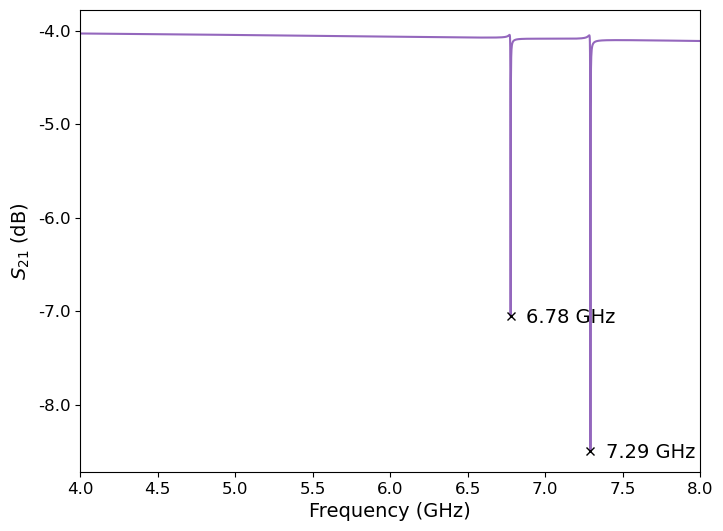

C0: [2.92098465e-14 3.39440332e-14]
Cc: [4.61314382e-15 3.84833757e-15]
Qc: [ 746.50144719 1113.96923099]


In [30]:
path = r'D:\AWR-MWO\202510-SiRes-NbTiN-Tres'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V16'
filecsv = 'Tres-V16.csv'


f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.2)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(4, 8)
ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-Tres-NbTiN\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 2


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

## V10

C:\Users\localadmin\AppData\Local\Temp\ipykernel_24740\3208561787.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_24740\3208561787.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)


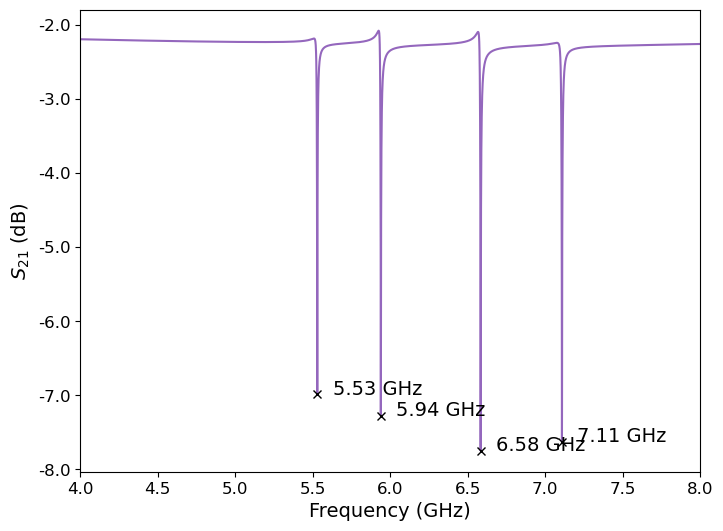

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)
name = 'Tress-test10'

f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp']-0.15, color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 1)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak]-0.15, 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(4, 8)
ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()


### Cap sim


In [61]:
path = r'D:\Ansys-Projects\202510-Tres-NbTiN'
file_list = os.listdir(path)
# print(file_list)

NoR = 4

for file in file_list:
    name = file.split('.')
    data = -1*pd.read_csv(os.path.join(path, file), skiprows=8, nrows = NoR+2)

print(data)
print(data.iloc[1,1])


C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_TressV10 = Qc(f0_si, C0, Cc)
print(f'Qc: {Qc_TressV10}')






  Unnamed: 0   Signal0_1   Signal0_2  Signal4_3  Signal4_5  Signal4_7  \
0            -950.095558  708.015896  33.012289  31.060091  28.420624   
1             708.015896 -757.317410  11.887247  11.050987  10.214149   
2              33.012289   11.887247 -45.457206   0.083372   0.015057   
3              31.060091   11.050987   0.083372 -42.641947   0.067536   
4              28.420624   10.214149   0.015057   0.067536 -39.095370   
5              26.488558   10.173780   0.002779   0.012553   0.056522   

   Signal4_8  Unnamed: 7  
0  26.488558         NaN  
1  10.173780         NaN  
2   0.002779         NaN  
3   0.012553         NaN  
4   0.056522         NaN  
5 -37.070472         NaN  
708.0158957572451
[5.5295 5.9395 6.5835 7.108 ]
Qc: [182.91256188 184.79680077 179.04709807 158.6200796 ]


## V11

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
dict_keys(['Tress-test10', 'V11'])


C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\578298129.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\578298129.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)


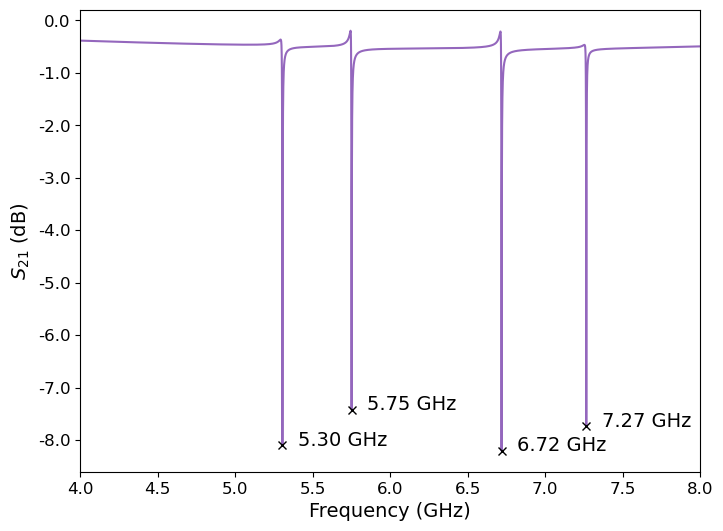

C0: [3.59173068e-13 3.40095558e-13 3.00920821e-13 2.85637736e-13]
Cc: [8.49645351e-16 7.32264206e-16 6.29195825e-16 5.62307391e-16]
Qc: [299267.94622177 351808.38655713 360882.23071164 396585.3075894 ]


In [20]:
path = r'D:\AWR-MWO\202510-SiRes-NbTiN-Tres'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V11'
filecsv = 'Tres-V11.csv'


f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp']-0.15, color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 1)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak]-0.15, 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(4, 8)
ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-Tres-NbTiN\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 4


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)*10
Cc = np.array(Cc)*0.1
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

In [14]:
path = r'D:\Ansys-Projects\202510-Tres-NbTiN\exports'
file_list = os.listdir(path)
# print(file_list)



NoR = 4

file = 'Tres-V11.csv'
data = -1*pd.read_csv(os.path.join(path, file), skiprows=8, nrows = NoR+2)

print(data)
print(data.iloc[1,1])


C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_TressV10 = Qc(f0_si, C0, Cc)
print(f'Qc: {Qc_TressV10}')

  Unnamed: 0   Signal0_1   Signal0_2  Signal4_3  Signal4_5  Signal4_7  \
0            -959.646263  707.716011  35.917307  34.009556  30.092082   
1             707.716011 -741.447307   8.496454   7.322642   6.291958   
2              35.917307    8.496454 -44.987704   0.089865   0.017355   
3              34.009556    7.322642   0.089865 -41.901271   0.074164   
4              30.092082    6.291958   0.017355   0.074164 -36.868014   
5              28.563774    5.623074   0.003432   0.015611   0.062543   

   Signal4_8  Unnamed: 7  
0  28.563774         NaN  
1   5.623074         NaN  
2   0.003432         NaN  
3   0.015611         NaN  
4   0.062543         NaN  
5 -34.625877         NaN  
707.7160110081056
[5.3045 5.751  6.7185 7.265 ]
Qc: [369.18823006 426.63811143 435.4287153  473.72464631]


# V13

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat', 'V13.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
['V13', 'mat']
dict_keys(['Tress-test10', 'V11', 'V13'])


C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\1495412614.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\1495412614.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)


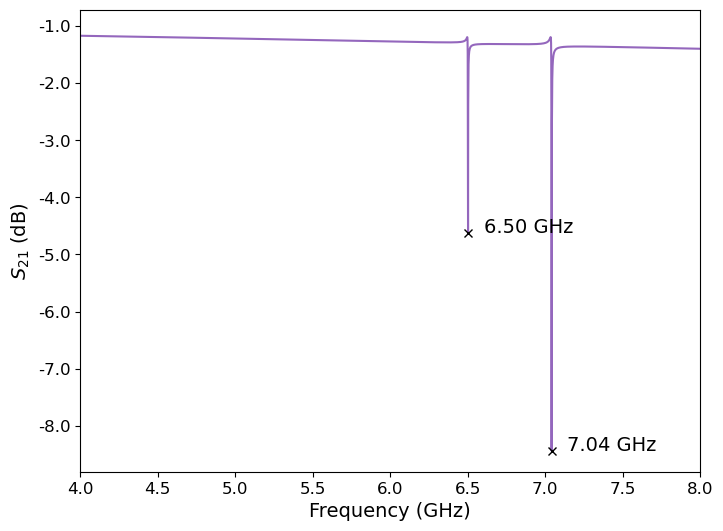

C0: [3.22643080e-14 2.93965613e-14]
Cc: [4.10447346e-15 4.86709221e-15]
Qc: [1056.82638949  653.87987182]


In [22]:
path = r'D:\AWR-MWO\202510-SiRes-NbTiN-Tres'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V13'
filecsv = 'Tres-V13.csv'


f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp']-0.15, color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 1)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak]-0.15, 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(4, 8)
ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-Tres-NbTiN\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 2


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V13 diff FL

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat', 'V13-diffFL.mat', 'V13.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
['V13-diffFL', 'mat']
['V13', 'mat']
dict_keys(['Tress-test10', 'V11', 'V13-diffFL', 'V13'])


C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\3149507817.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\3149507817.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)


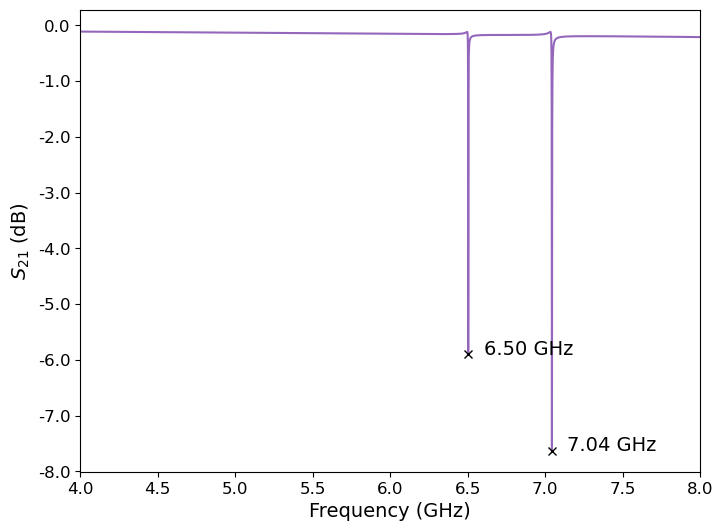

C0: [3.15201666e-14 2.85928229e-14]
Cc: [4.83170056e-15 5.63273791e-15]
Qc: [762.14281671 487.5052075 ]


In [23]:
path = r'D:\AWR-MWO\202510-SiRes-NbTiN-Tres'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V13-diffFL'
filecsv = 'Tres-V13-diffFL.csv'


f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp']-0.15, color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 1)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak]-0.15, 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(4, 8)
ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-Tres-NbTiN\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 2


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V14

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat', 'V13-diffFL.mat', 'V13.mat', 'V14.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
['V13-diffFL', 'mat']
['V13', 'mat']
['V14', 'mat']
dict_keys(['Tress-test10', 'V11', 'V13-diffFL', 'V13', 'V14'])


C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\105783763.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\105783763.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)


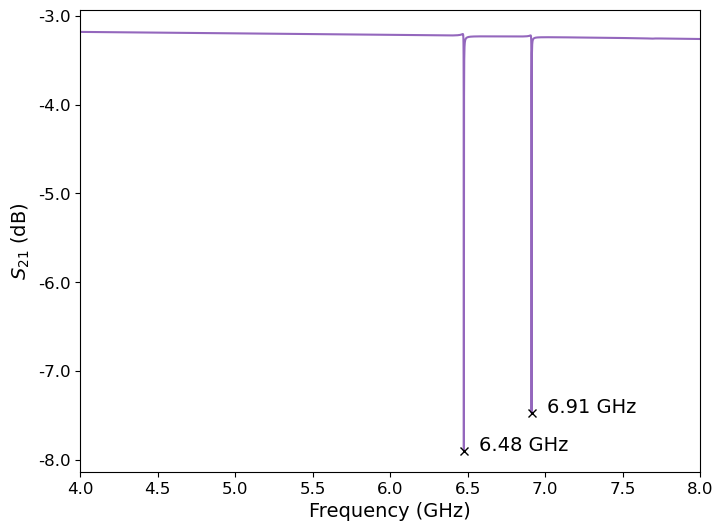

C0: [3.33932199e-14 3.26123673e-14]
Cc: [3.36601753e-15 3.21850583e-15]
Qc: [1594.88982355 1592.92448932]


In [ ]:
path = r'D:\AWR-MWO\202510-SiRes-NbTiN-Tres'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V14'
filecsv = 'Tres-V14.csv'


f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp']-0.15, color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 1)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak]-0.15, 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(4, 8)
ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-Tres-NbTiN\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 2


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V15

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat', 'V13-diffFL.mat', 'V13.mat', 'V14.mat', 'V15.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
['V13-diffFL', 'mat']
['V13', 'mat']
['V14', 'mat']
['V15', 'mat']
dict_keys(['Tress-test10', 'V11', 'V13-diffFL', 'V13', 'V14', 'V15'])


C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\3996773739.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_26228\3996773739.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)


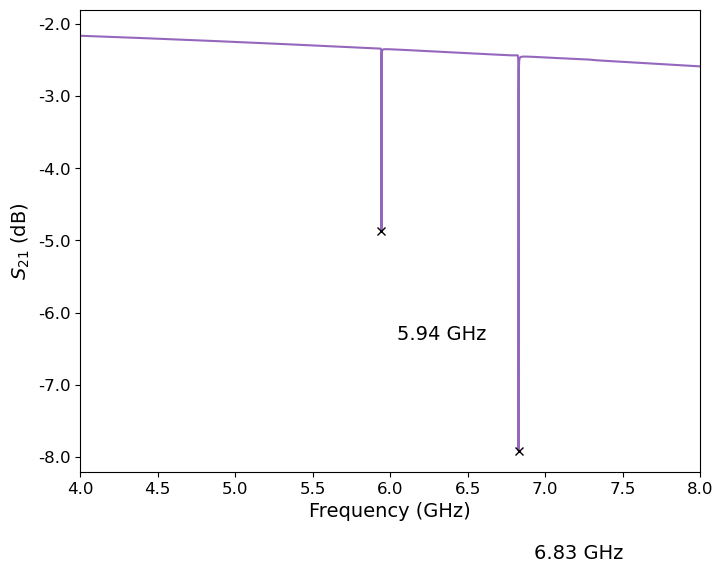

C0: [3.89931437e-14 3.48077648e-14]
Cc: [1.65557123e-15 1.96805082e-15]
Qc: [7942.39777664 4426.35570035]


In [28]:
path = r'D:\AWR-MWO\202510-SiRes-NbTiN-Tres'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V15'
filecsv = 'Tres-V15.csv'


f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.2)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(4, 8)
ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-Tres-NbTiN\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 2


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# old stuff

In [121]:
import pandas as pd
path = r'C:\Users\LocalAdmin\OneDrive - Delft University of Technology\Sim-data-Al\ansys\new-diel'
file_list = os.listdir(path)
# print(file_list)
C0_ge = []
C0_si= []
C0_hetero_si = []
C0_hetero_ge = []
Cc_ge = []
Cc_si = []
Cc_hetero_si = []
Cc_hetero_ge = []

for file in file_list:
    name = file.split('.')
    if name[0] == 'c0-si':
        C0_si = -1*np.array(pd.read_csv(os.path.join(path, file)).values[0][1:])
    elif name[0] == 'cc-si':
        Cc_si = -1*np.array(pd.read_csv(os.path.join(path, file)).values[0][1:])
    elif name[0] == 'c0-ge-subs':
        C0_ge = -1*np.array(pd.read_csv(os.path.join(path, file)).values[0][1:])
    elif name[0] == 'cc-ge-subs':
        Cc_ge = -1*np.array(pd.read_csv(os.path.join(path, file)).values[0][1:])
    elif name[0] == 'c0-hetero-si':
        C0_hetero_si = -1*np.array(pd.read_csv(os.path.join(path, file)).values[0][1:])
    elif name[0] == 'cc-hetero-si':
        Cc_hetero_si = -1*np.array(pd.read_csv(os.path.join(path, file)).values[0][1:])
    elif name[0] == 'c0-hetero-ge':
        C0_hetero_ge = -1*np.array(pd.read_csv(os.path.join(path, file)).values[0][1:])
    elif name[0] == 'cc-hetero-ge':
        Cc_hetero_ge = -1*np.array(pd.read_csv(os.path.join(path, file)).values[0][1:])
    

In [ ]:
def Qc(f0, C0, Cc):
    return 1e15*(C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_ge = Qc(np.array(f0_ge), C0_ge, Cc_ge)
Qc_si = Qc(np.array(f0_si), C0_si, Cc_si)
Qc_hetero_si = Qc(np.array(f0_hetero_si), C0_hetero_si, Cc_hetero_si)
# Qc_hetero_ge = Qc(np.array(f0_hetero_ge), C0_hetero_ge, Cc_hetero_ge)

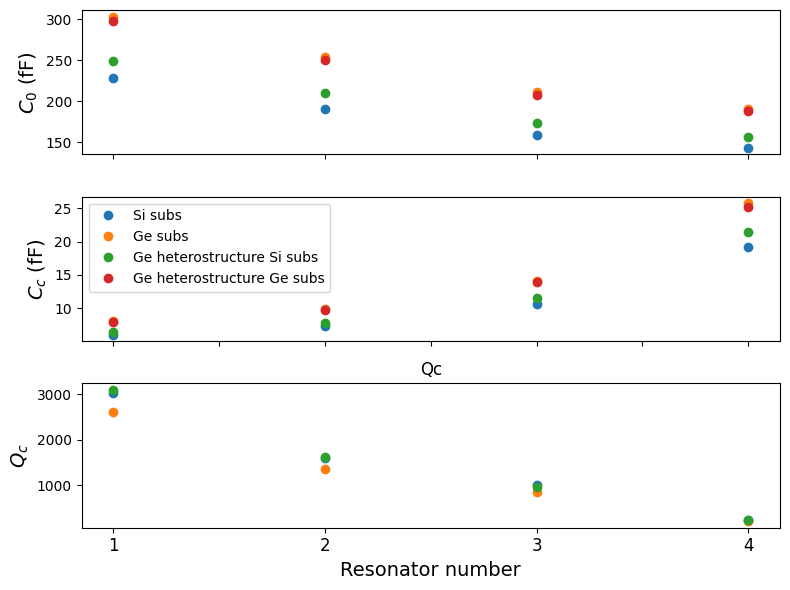

In [ ]:
fig, ax = plt.subplots(3,1,figsize=(8, 6))

ax[0].plot(C0_si,'o', label='Si subs')
ax[0].plot(C0_ge, 'o',label='Ge subs')
ax[0].plot(C0_hetero_si, 'o', label='Ge heterostructure Si subs' )
ax[0].plot(C0_hetero_ge,'o', label='Ge heterostructure Ge subs')
# ax[0].set_title('$C_0$')
# ax[0].set_xlabel('Resonator number')
ax[0].set_xticks(np.arange(len(C0_si)))
ax[0].set_xticklabels('')
ax[0].set_ylabel('$C_0$ (fF)', fontsize=14)
# ax[0].legend()
ax[1].plot(Cc_si,'o', label='Si subs')
ax[1].plot(Cc_ge, 'o',label='Ge subs')
ax[1].plot(Cc_hetero_si, 'o',label='Ge heterostructure Si subs')
ax[1].plot(Cc_hetero_ge,'o', label='Ge heterostructure Ge subs')
# ax[1].set_title('$C_c$')
# ax[1].set_xticks(np.arange(len(C0_si)))
ax[1].set_xticklabels('')
# ax[1].set_xlabel('Resonator number')
ax[1].set_ylabel('$C_c$ (fF)', fontsize=14)
ax[1].legend()
ax[2].plot(Qc_si,'o', label='Si subs')
ax[2].plot(Qc_ge, 'o',label='Ge subs')
ax[2].plot(Qc_hetero_si, 'o',label='Ge heterostructure Si subs')
# ax[2].plot(Qc_hetero_ge,'o', label='Ge heterostructure Ge subs')
ax[2].set_title('Qc')
ax[2].set_xticks(np.arange(len(C0_si))) 
ax[2].set_xticklabels(np.arange(1, len(C0_si)+1), fontsize=12)
ax[2].set_xlabel('Resonator number', fontsize=14)
ax[2].set_ylabel('$Q_c$', fontsize=14)

plt.tight_layout()
# plt.savefig(r'C:\Users\LocalAdmin\OneDrive - Delft University of Technology\gonogo-pics\cap_sim.png', dpi=300)


In [6]:
import pandas as pd
# Load the data ; 0th dimension for 0p6, 1st for 0p3
C0_0p6 = []
C0_0p3 = []
Cc_0p6 = []
Cc_0p3 = []
C0_ge = []
Cc_ge = []
for file in file_list[:-2]:
    name = file.split('.')
    if name[1] == 'csv':
        d = pd.read_csv(os.path.join(path,file))
        if name [0][0:2] == 'c0':
            if name[0][-1] == '6':
                print(name)
                C0_0p6 = -1*np.array(d.values[0][1:])
            elif name[0][-1] == '3':
                print(name)
                C0_0p3 = -1*np.array(d.values[0][1:])
            elif name[0][-1]== 'e':
                C0_ge = -1*np.array(d.values[0][1:])
        elif name[0][0:2] == 'cc':
            if name[0][-1] == '6':
                print(name)
                Cc_0p6 = -1*np.array(d.values[0][1:])
            elif name[0][-1] == '3':
                print(name)
                Cc_0p3 = -1*np.array(d.values[0][1:])
            elif name[0][-1]== 'e':
                Cc_ge = -1*np.array(d.values[0][1:])

print(C0_0p6)
print(C0_0p3)
print(Cc_0p6)
print(Cc_0p3)
print(C0_ge)
print(Cc_ge)


['c0-0p3', 'csv']
['c0-0p6', 'csv']
['cc-0p3', 'csv']
['cc-0p6', 'csv']
[226.62439328 189.87921755 157.97328313 142.28272196]
[202.19848849 180.99944855 147.4741042  132.55380876]
[ 6.05268197  7.2994568  10.55836593 19.18854841]
[ 5.84695264  7.09925527 10.37442126 18.90144838]
[250.55605914 209.18869635 174.38944843 157.06324454]
[ 6.4207344   7.80772817 11.49557818 21.87051198]


In [8]:
# print nicely 
print(f'0.6um C0: {C0_0p6}')
print(f'0.3um C0: {C0_0p3}')
print(f'0.6um Cc: {Cc_0p6}')
print(f'0.3um Cc: {Cc_0p3}')
# print(f'0.6um f0: {f0_0p6}')
# print(f'0.3um f0: {f0_0p3}')
print(f'0.6um C0 ge: {C0_ge}')
print(f'0.6um Cc ge: {Cc_ge}')





0.6um C0: [226.62439328 189.87921755 157.97328313 142.28272196]
0.3um C0: [202.19848849 180.99944855 147.4741042  132.55380876]
0.6um Cc: [ 6.05268197  7.2994568  10.55836593 19.18854841]
0.3um Cc: [ 5.84695264  7.09925527 10.37442126 18.90144838]
0.6um C0 ge: [250.55605914 209.18869635 174.38944843 157.06324454]
0.6um Cc ge: [ 6.4207344   7.80772817 11.49557818 21.87051198]


In [13]:
#Qc
def Qc(f0, C0, Cc):
    return 1e15*(C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_0p6 = Qc(f0_0p6, C0_0p6, Cc_0p6)
Qc_0p3 = Qc(f0_0p3, C0_0p3, Cc_0p3)
print(f'0.6um Qc: {Qc_0p6}')
print(f'0.3um Qc: {Qc_0p3}')
Qc_ge = Qc(f0_0p6, C0_ge, Cc_ge)
print(f'0.6um Qc ge: {Qc_ge}')

0.6um Qc: [4205.12638497 2075.10793655  720.50106319  189.78192594]
0.3um Qc: [3753.68755357 1981.95806571  688.9999301   175.38031258]
0.6um Qc ge: [4127.10637279 1996.02070828  670.39280488  161.88932481]
